In [1]:
import gym
import talib
import numpy as np
import pandas as pd
import math
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import get_schedule_fn
from gym import spaces
import torch.nn as nn
import torch as th
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.ppo.policies import MlpPolicy
from stable_baselines3.common.vec_env import SubprocVecEnv
import torch
import os

sequence_len = 1
use_gpu = False
use_prev_action = False
use_comission = True
punish_negatives_extra = False

if use_gpu:
    os.environ["PYTORCH_DISABLE_MODEL_LOADING_RAM_OPTIMIZATION"] = "1"
    torch.set_default_dtype(torch.float32)  # Ensure all tensors use float32
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = "cpu"

%run "../helpers/data_manipulator.py"

all_data = None
all_data_np = None

class TradingEnv(gym.Env):
    def __init__(self, data, initial_balance=100000):
        super(TradingEnv, self).__init__()
        self.data = data
        self.tickers = my_stocks
        self.lambda_penalty = 0.002
        self.initial_balance = initial_balance
        self.current_step = 0  # Start at 201 for history
        # self.max_steps = len(self.data[self.data["TICKER"] == my_stocks[0]]) - self.current_step
        self.max_steps = len(self.data) - self.current_step
        self.cash_balance = self.initial_balance
        self.positions = np.zeros(len(my_stocks))
        self.last_prices = np.zeros(len(my_stocks))
        self.total_reward = 1.0
        self.average_buy_prices = np.zeros(len(my_stocks))

        
        num_features = data.shape[3]#  - 2  # Exclude price column
        print(f"num_features: {num_features}")
        
        # Action space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Box(low=0.05, high=0.25, shape=(len(my_stocks) + 1,), dtype=np.float32)
        
        self.prev_action = np.ones(self.action_space.shape, dtype=np.float32) / (len(my_stocks) + 1)
        
        # Observation space: Last sequence_len days of features
        # self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(my_stocks), sequence_len, num_features), dtype=np.float32)

        self.observation_space = spaces.Dict({
            "obs": spaces.Box(low=-np.inf, high=np.inf, shape=(len(my_stocks), sequence_len, num_features), dtype=np.float32),
            "prev_action": spaces.Box(low=0.0, high=1.0, shape=(len(my_stocks) + 1,), dtype=np.float32)
        })

    def seed(self, seed=None):
        """Set the seed for this environment's random number generator."""
        self.np_random, seed = gym.utils.seeding.np_random(seed)
        return [seed]
        
    def reset(self):
        self.current_step = 0
        self.tickers = my_stocks
        self.cash_balance = self.initial_balance
        self.positions = np.zeros(len(my_stocks))
        self.last_prices = np.zeros(len(my_stocks))
        self.total_reward = 1.0
        self.average_buy_prices = np.zeros(len(my_stocks))
        self.prev_action = np.ones(self.action_space.shape, dtype=np.float32) / (len(my_stocks) + 1)
        
        return self._next_observation()

    def _next_observation(self):
        
        return {
            "obs": self.data[self.current_step],  # Current observation
            "prev_action": self.prev_action  # Previously taken action
        }
    
    def step(self, action):

        
        # print(f"actions: {action}")
        epsilon = 1e-8  # Small constant to prevent division by zero
        action /= (np.sum(action) + epsilon)
    
        ideal_value = 1 / len(action)  # 0.0909 for 11 actions
        penalty_strength = 0.03 / len(action)   # Tune this value to adjust punishment effect
        penalty = 0#-penalty_strength * np.sum(np.abs(action - ideal_value))

        
        today_value = self.cash_balance
        tomorrow_value_if_no_change = self.cash_balance + (self.cash_balance * 0.04 / 365)
        tomorrow_value_with_change = 0
        tomorrow_value_with_change_capped = 0
        reward = 0

        if use_comission:
            comission = 0.002
        else:
            comission = 0.0
        
        upper_cap = 1.05
        lower_cap = 0.95
        cash_interest = 0.04

        for i, ticker in enumerate(my_stocks):
            today_stock_price = all_data_np[i, self.current_step]
            tomorrow_stock_price = all_data_np[i, self.current_step + 1]
            tomorrow_stock_price_capped = max(min(tomorrow_stock_price, today_stock_price * upper_cap), today_stock_price * lower_cap)
            today_value += today_stock_price * self.positions[i]
            tomorrow_value_if_no_change += tomorrow_stock_price_capped * self.positions[i]
            # print(f"current step: {self.current_step} ticker: {ticker}, today_stock_price: {today_stock_price}")

        # print(action)
        for i, act in enumerate(action):
            if i == len(action) - 1:
                ## MEANS THE CASH TO HOLD
                break
                
            ticker = self.tickers[i]
            
            today_stock_price = all_data_np[i, self.current_step]
            tomorrow_stock_price = all_data_np[i, self.current_step + 1]
            tomorrow_stock_price_capped = max(min(tomorrow_stock_price, today_stock_price * upper_cap), today_stock_price * lower_cap)
            
            today_stock_allocation = (today_stock_price * self.positions[i]) / today_value
            self.last_prices[i] = today_stock_price
            
            if act > today_stock_allocation and act > 0:
                desired_invest = act * today_value
                current_invest = today_stock_price * self.positions[i]
                diff = desired_invest - current_invest
                amount_to_buy = math.floor((diff / today_stock_price) * (1 - comission))
                if amount_to_buy > 0:
                    self.positions[i] += amount_to_buy
                    self.cash_balance -= (today_stock_price * amount_to_buy) * (1 + comission)
                    if self.positions[i] > 0:
                        self.average_buy_prices[i] = ((self.average_buy_prices[i-1] * self.positions[i-1]) + (today_stock_price * amount_to_buy)) / self.positions[i]
                    else:
                        self.average_buy_prices[i] = current_price
            elif act < today_stock_allocation:
                desired_invest = act * today_value
                current_invest = today_stock_price * self.positions[i]
                diff = current_invest - desired_invest
                amount_to_sell = math.ceil(diff / today_stock_price)
                if amount_to_sell > 0:
                    self.positions[i] -= amount_to_sell
                    self.cash_balance += (today_stock_price * amount_to_sell) * (1 - comission)
                    
            tomorrow_value_with_change += tomorrow_stock_price * self.positions[i]
            tomorrow_value_with_change_capped += tomorrow_stock_price_capped * self.positions[i]

        
        self.cash_balance = self.cash_balance + self.cash_balance * cash_interest / 365
        tomorrow_value_with_change += self.cash_balance
        tomorrow_value_with_change_capped += self.cash_balance

        # print(f"tomorrow_value_with_change: {tomorrow_value_with_change}, tomorrow_value_if_no_change: {tomorrow_value_if_no_change}")
        # print(f"capped reward: {tomorrow_value_with_change_capped / tomorrow_value_if_no_change - 1.0} normal reward: {tomorrow_value_with_change / tomorrow_value_if_no_change - 1.0}")
        reward += tomorrow_value_with_change_capped / tomorrow_value_if_no_change - 1.0
        reward += penalty
        # if reward < -0.008:
        #     reward *= 4
        
        if punish_negatives_extra and reward < 0:
            reward *= 2
        # reward = min(0.035, reward)
        # reward = max(-0.03, reward)
        # reward = torch.log(torch.tensor(reward + 1))

        # 🔥 Compute the penalty: L2 norm of allocation change
        # action_change_penalty = np.linalg.norm(action - self.prev_action)

        # Compute final penalized reward
        # reward = reward - self.lambda_penalty * action_change_penalty

        # diff = 0.0
        # upper_threshold = max((1.0 / len(action)), 0.25)
        # lower_threshold = min((1.0 / len(action)), 0.05)
        # for i, act in enumerate(action):
        #     if act > upper_threshold:
        #         diff += act - upper_threshold
        #     elif act < lower_threshold:
        #         diff += lower_threshold - act
        # punishment = 0.01 * diff
        # reward -= punishment
        
        self.current_step += 1
        # print(f"self.data.shape[0]: {self.data.shape[0]}")
        done = self.current_step >= self.data.shape[0] - 1
        
        # Store action for next timestep
        self.prev_action = action

        reward = 1000 * torch.log(torch.tensor(reward + 1))
        # print(f"reward: {reward}")
        
        obs = self._next_observation()
        self.total_reward *= reward
        return obs, reward, done, {}

all_data = pd.DataFrame()
all_data_val = pd.DataFrame()

for ticker in my_stocks:
    # GET RAW DATA FOR THE TICKER
    stock_file, earnings_file = fetch_finance_data_for_tickers(ticker, "10y", refresh=False, verbose=False, incl_earnings=True)
    data = pd.read_csv(stock_file)
    earnings = pd.read_csv(earnings_file)
    data = data.drop(data[data['Volume'] == 0].index)
    data.reset_index(drop=True, inplace=True)
    data = make_new_features_for(data, earnings=earnings, use_adj_close=True)
    data, data_val, _ = split_data(data,
                                train_cut_date = "2024-07-01",
                                validate_cut_date = "2025-03-01",
                                test_end_date = "2025-03-10",
                                train_start_date = "2016-07-01"
                               )
    print(f"ticker: {ticker} ::: data_val: {data_val}")
    normalized_data = normalize_data(data, ticker)
    normalized_data_val = normalize_data(data_val, ticker)
    normalized_data["Close"] = data["Adj Close"]
    normalized_data_val["Close"] = data_val["Adj Close"]
    data = normalized_data
    data_val = normalized_data_val
    all_data = pd.concat([all_data, data], ignore_index=True)
    all_data_val = pd.concat([all_data_val, data_val], ignore_index=True)


features_to_use = lstm_features_v2 + extra_dense_layers_features
    
print("Maximum values:\n", all_data[features_to_use].iloc[0:].max().to_dict())
print("\nMinimum values:\n", all_data[features_to_use].iloc[0:].min().to_dict())
    

obs = []
obs_val = []
for ticker in my_stocks:
    ticker_data = all_data[all_data["TICKER"] == ticker]
    ticker_data_val = all_data_val[all_data_val["TICKER"] == ticker]
    
    dat = ticker_data[features_to_use]
    dat = dat.values  

    dat_val = ticker_data_val[features_to_use]
    dat_val = dat_val.values
    
    # Create the sliding window array
    result = np.array([dat[i - (sequence_len-1):i+1] for i in range(sequence_len-1, len(dat))])
    result_val = np.array([dat_val[i - (sequence_len-1):i+1] for i in range(sequence_len-1, len(dat_val))])
    
    # Result shape: (100 - 20, 21, 3) → (80, 21, 3)
    print(result.shape)  # Should print (80, 21, 3)
    print(result_val.shape)  # Should print (80, 21, 3)

    obs.append(result)
    obs_val.append(result_val)

    

# print(obs.to_numpy())
obs = np.array(obs)
obs = obs.transpose(1, 0, 2, 3)
obs = obs.astype(np.float32)
print(obs.shape)

# print(obs.to_numpy())
obs_val = np.array(obs_val)
obs_val = obs_val.transpose(1, 0, 2, 3)
obs_val = obs_val.astype(np.float32)
print(obs_val.shape)




unique_tickers = all_data["TICKER"].unique()

# Convert to a 2D array where rows = tickers, cols = Close values
all_data_np = np.array([all_data[all_data["TICKER"] == ticker]["Close"].values for ticker in unique_tickers], dtype=object)
all_data_np_val = np.array([all_data_val[all_data_val["TICKER"] == ticker]["Close"].values for ticker in unique_tickers], dtype=object)

all_data_np = all_data_np[:, sequence_len-1:]
all_data_np_val = all_data_np_val[:, sequence_len-1:]


print(f"all_data_np.shape: {all_data_np.shape}")

# Setup Environment
env = DummyVecEnv([lambda: TradingEnv(obs)])

env.tickers = my_stocks

def calculate_output_for_cnn(initial_len, cnn_depth=3):
    affect = math.floor((initial_len-1)/2)
    if (cnn_depth == 1): 
        return affect
    else:
        return calculate_output_for_cnn(affect, cnn_depth-1)

class SharedStockNetwork(BaseFeaturesExtractor):
    def __init__(self, observation_space: spaces.Dict, num_stocks, input_dim):

        total_end = 100
        
        obs_dim = observation_space.spaces["obs"].shape[0]
        action_dim = observation_space.spaces["prev_action"].shape[0]
        print(f"obs_dim: {obs_dim}, action_dim: {action_dim}, num_stocks: {num_stocks}")
        total_input_dim = obs_dim + action_dim  # Combined input

        features_dim = num_stocks #+ action_dim # Must match final layer output
        
        # self.daily_dense_output = 83
        self.daily_dense_output = 8
        cnn_end = 8

        stocks_output = num_stocks * cnn_end
        total_output = stocks_output * 2
        if use_prev_action:
            total_output += action_dim
        super(SharedStockNetwork, self).__init__(observation_space, 
                                                 total_output)
        # super(SharedStockNetwork, self).__init__(observation_space, total_end)

        self.shared_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * sequence_len, 32),
            nn.ReLU(),
        )
        
        self.daily_stock_dense = nn.Sequential(
            nn.Dropout(p=0.18),
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(),
            nn.Dropout(p=0.16),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Dropout(p=0.14),
            nn.Linear(16, 16),
            nn.LeakyReLU(),
            nn.Dropout(p=0.12),
            nn.Linear(16, 4),
            nn.LeakyReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(4, self.daily_dense_output),
            nn.Sigmoid(),
        )

        # Create a separate daily_stock_dense for each stock
        self.daily_stock_dense_list = nn.ModuleList([
            nn.Sequential(
                # nn.Dropout(p=0.10),
                nn.Linear(input_dim, 128),
                nn.BatchNorm1d(128),
                nn.LeakyReLU(),
                # nn.Dropout(p=0.10),
                nn.Linear(128, 128),
                nn.BatchNorm1d(128),
                nn.LeakyReLU(),
                nn.Linear(128, 64),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                # nn.Dropout(p=0.08),
                nn.Linear(64, 64),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.LeakyReLU(),
                # nn.Dropout(p=0.08),
                # nn.Linear(16, 16),
                # nn.ReLU(),
                # nn.Dropout(p=0.08),
                # nn.Linear(8, 4),
                # nn.ReLU(),
                # nn.Dropout(p=0.1),
                nn.Linear(32, self.daily_dense_output),
                # nn.BatchNorm1d(self.daily_dense_output),
                nn.LeakyReLU(),
            ) for _ in range(num_stocks)  # Create a unique layer for each stock
        ])

        if sequence_len > 1:
            # 1D Convolution across stocks
            self.conv = nn.Sequential(
                # nn.BatchNorm1d(self.daily_dense_output),
                nn.Conv1d(
                    in_channels=input_dim,  # Convolution across stocks, not features
                    out_channels=64,  # Number of filters
                    kernel_size=3
                ),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                nn.Conv1d(
                    in_channels=64,  # Convolution across stocks, not features
                    out_channels=64,  # Number of filters
                    kernel_size=3,  # Consider 3 neighboring stocks
                    stride=2
                ),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                nn.Conv1d(
                    in_channels=64,  # Convolution across stocks, not features
                    out_channels=64,  # Number of filters
                    kernel_size=3,  # Consider 3 neighboring stocks
                    stride=2
                ),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(),
                nn.Flatten(),
                nn.Linear(64 * calculate_output_for_cnn(sequence_len-2, 2), 512),
                nn.BatchNorm1d(512),
                nn.LeakyReLU(),
                nn.Linear(512, 128),
                nn.BatchNorm1d(128),
                nn.LeakyReLU(),
                nn.Linear(128, cnn_end),
                nn.BatchNorm1d(cnn_end),
                nn.LeakyReLU(),
                # nn.Sigmoid(),
                # nn.Linear(128, 32),
                # nn.ReLU(),
                # nn.Linear(128, cnn_end),
                # nn.BatchNorm1d(cnn_end),
                # nn.LeakyReLU()
                # nn.Sigmoid(),
            )
        # 1D Convolution across stocks
        self.stock_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=cnn_end,  # Convolution across stocks, not features
                out_channels=1000,  # Number of filters
                kernel_size=10
            ),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(1000, total_end),
            nn.ReLU(),
        )

        self.fc_after_combined_cnn = nn.Sequential(
            nn.Linear(num_stocks * cnn_end , num_stocks * cnn_end * 2),
            nn.ReLU(),
            nn.Linear(num_stocks * cnn_end * 2 , num_stocks * cnn_end),
            nn.ReLU(),
        )
        self.prev_action_fc = nn.Sequential(
            nn.Linear(action_dim, action_dim),
            nn.ReLU()
        )
        
        self.fully_connected = nn.Sequential(
            nn.Linear(stocks_output, stocks_output * 2),
            nn.BatchNorm1d(stocks_output * 2),
            nn.LeakyReLU(),
            # nn.Linear(stocks_output * 4, stocks_output * 2),
            # nn.BatchNorm1d(stocks_output * 2),
            # nn.LeakyReLU(),
            # nn.Linear(stocks_output * 2, stocks_output),
            # nn.BatchNorm1d(stocks_output),
            # nn.LeakyReLU(),
            # nn.Linear(total_output * 2, total_output),
            # nn.ReLU()
        )

        self.flatten = nn.Sequential(
            nn.Flatten()
        )
    
    def forward(self, observations):
        obs = observations["obs"]
        prev_action = observations["prev_action"]

        # print(f"x.shape: {x.shape}")
        batch_size, num_stocks, sequence_len, features_len = obs.shape
        # print(f"batch_size, num_stocks, sequence_len, features_len: {batch_size, num_stocks, sequence_len, features_len}")
        
        # x = x.permute(0, 2, 1)  # Move stock dimension to be iterated
        # shared_outputs = [self.shared_layers(x[:, i, :, :]) for i in range(num_stocks)]
        # combined = torch.cat(shared_outputs, dim=-1)
        # final_layer = self.final_layer(combined)
        # flatten = self.flatten(final_layer)
        # return self.fully_connected(flatten)

        # # Apply a different `daily_stock_dense` layer for each stock
        # daily_results = []
        # for i in range(num_stocks):
        #     daily = obs[:, i, :, :].view(-1, features_len)  # Extract data for stock i
        #     daily_result = self.daily_stock_dense_list[i](daily)  # Use specific layer for stock i
        #     daily_results.append(daily_result)

        # # Stack results back together
        # daily_result = torch.stack(daily_results, dim=1).view(batch_size, num_stocks, sequence_len, self.daily_dense_output)

        
        # # Stack the results to match the original stock dimension
        if sequence_len > 1:
            output = obs
        else:
            daily_results = []
            for i in range(num_stocks):
                # Extract data for stock i across all batches and sequences
                daily = obs[:, i, :, :].reshape(-1, features_len)  # Ensures correct reshaping
                
                # Apply the corresponding dense layer for this stock
                daily_result = self.daily_stock_dense_list[i](daily)  
            
                # Reshape back to match batch and sequence dimensions
                daily_results.append(daily_result.view(batch_size, sequence_len, -1))
            
            output = torch.stack(daily_results, dim=1)  # Shape: (batch_size, num_stocks, sequence_len, dense_output_size)

        
        # print(f"obs.shape: {obs.shape}")
        # daily = obs.view(-1, features_len)
        # daily_result = self.daily_stock_dense(daily)
        # print(f"daily_result.shape: {daily_result.shape}")
        
        # Step 3: Reshape back to (batch_size, stocks, sequence)
        # daily_result = daily_result.view(batch_size, num_stocks, sequence_len, self.daily_dense_output)
        # print(f"daily_result.shape2: {daily_result.shape}")

        obs_shaped = output.permute(0, 1, 3, 2)
        if sequence_len > 1:
            stock_outputs = torch.stack([self.conv(obs_shaped[:, i, :, :]) for i in range(num_stocks)], dim=1)
        else:
            stock_outputs = torch.stack([self.flatten(obs_shaped[:, i, :, :]) for i in range(num_stocks)], dim=1)
        
        # stock_outputs = stock_outputs.permute(0, 2, 1)
        # double_cnn_outputs = self.stock_conv(stock_outputs)
        
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        # all_stocks_output = self.final_layer(stock_outputs)
        
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        stock_outputs = stock_outputs.flatten(start_dim=1)
        double_cnn_outputs = stock_outputs #self.fc_after_combined_cnn(stock_outputs)
        # print(f"stock_outputs.shape: {stock_outputs.shape}")
        
        ## POLICY
        # stock_outputs = torch.stack([self.shared_layers(obs[:, i, :, :]) for i in range(num_stocks)], dim=1)
        
        
        # prev_actions_outputs = self.prev_action_fc(prev_action)
        # combined = torch.cat([double_cnn_outputs, prev_action], dim=1)
        # policy_net = self.fully_connected(combined)
        

        policy_net = self.fully_connected(double_cnn_outputs)
        if use_prev_action:
            policy_net = torch.cat([policy_net, prev_action], dim=1)
        
        ## VALUE
        # stock_outputs = torch.stack([self.shared_layers(obs[:, i, :, :]) for i in range(num_stocks)], dim=1)
        # value_net = self.final_layer(stock_outputs)
        
        # combined = torch.cat([all_stocks_output, prev_action], dim=1)
        
        # print(f"ASDASFD:{shared_outputs.shape}")
        # shared_outputs = shared_outputs.permute(0, 2, 1)  # (batch, features_dim, stocks)
        # conv_outputs = self.conv(shared_outputs)
        # x = x.view(batch_size * num_stocks, sequence_len, features_len)  # Flatten stock dimension
        # shared_outputs = self.shared_layers(x)  # Process all stocks in parallel
        # shared_outputs = shared_outputs.view(batch_size, num_stocks, -1)  # Reshape back
        # combined = shared_outputs.flatten(start_dim=1)  # Flatten stock outputs

        
        return policy_net
        # return all_stocks_output
        
        

from stable_baselines3.common.policies import MultiInputActorCriticPolicy
# import torch.nn as nn
# import torch.nn.functional as F
# from stable_baselines3.common.distributions import Distribution
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# 
# class DirichletDistribution(Distribution):
#     def __init__(self, action_dim):
#         super(DirichletDistribution, self).__init__()
#         self.action_dim = action_dim
#         # Learnable exploration parameter
#         self.exploration_param = nn.Parameter(torch.tensor(1.0, requires_grad=True))
        
#     def proba_distribution_net(self, latent_dim):
#         # Just a linear layer to produce concentration parameters
#         concentration_params = nn.Linear(latent_dim, self.action_dim)
#         return concentration_params
        
#     def proba_distribution(self, concentration_logits):
#         # Dynamic concentration with exploration scaling
#         scaling = torch.sigmoid(self.exploration_param)
        
#         # Apply dynamic scaling and add noise
#         self._concentration = (F.softplus(concentration_logits * scaling) * 0.5) + 0.5
        
#         # Ensure minimum concentration
#         self._concentration = torch.clamp(self._concentration, min=0.1)
        
#         # Add small random noise to encourage exploration
#         noise = torch.randn_like(self._concentration) * 0.1 * scaling
#         self._concentration += noise
        
#         # Create the Dirichlet distribution
#         self._dirichlet = torch.distributions.Dirichlet(self._concentration)
#         return self
    
#     def entropy(self):
#         # Dynamically scaled entropy with exploration parameter
#         base_entropy = self._dirichlet.entropy()
#         exploration_scale = torch.abs(self.exploration_param)
        
#         # Adaptive entropy calculation with sigmoid scaling
#         adaptive_entropy = base_entropy * torch.sigmoid(exploration_scale)
        
#         return adaptive_entropy.unsqueeze(-1)
    
#     def actions_from_params(self, concentration_logits, deterministic=False):
#         self.proba_distribution(concentration_logits)
#         if deterministic:
#             actions = self.mode()
#         else:
#             actions = self.sample()
#         log_prob = self.log_prob(actions)
#         return actions, log_prob
    
#     def log_prob_from_params(self, concentration_logits, actions=None, deterministic=False):
#         self.proba_distribution(concentration_logits)
        
#         if actions is None:
#             if deterministic:
#                 actions = self.mode()
#             else:
#                 actions = self.sample()
        
#         log_prob = self.log_prob(actions)
#         return actions, log_prob
        
#     def log_prob(self, actions):
#         return self._dirichlet.log_prob(actions).unsqueeze(-1)
        
#     def sample(self):
#         return self._dirichlet.sample()
        
#     def mode(self):
#         return self._concentration / torch.sum(self._concentration, dim=1, keepdim=True)
        

# class DirichletMultiInputPolicy(MultiInputActorCriticPolicy):
#     def __init__(self, *args, **kwargs):
#         super().__init__(*args, **kwargs)
#         action_dim = self.action_space.shape[0]
#         self.action_dist = DirichletDistribution(action_dim)
    
#     def _get_action_dist_from_latent(self, latent_pi):
#         # Get the concentration parameters from the action net
#         concentration_logits = self.action_net(latent_pi)
        
#         # Explicitly print or log the exploration parameter
#         print(f"Exploration Parameter: {self.action_dist.exploration_param.data}")
        
#         # Use our Dirichlet distribution
#         return self.action_dist.proba_distribution(concentration_logits)
    
#     def evaluate_actions(self, obs, actions):
#         # Override to ensure our custom entropy is used
#         latent_pi, latent_vf, _ = self.mlp_extractor(self.extract_features(obs))
        
#         # Get distribution from latent
#         distribution = self._get_action_dist_from_latent(latent_pi)
        
#         # Calculate log probabilities
#         log_prob = distribution.log_prob(actions)
        
#         # Use our custom entropy calculation
#         entropy = distribution.entropy()
        
#         # Value function
#         values = self.value_net(latent_vf)
        
#         return values, log_prob, entropy

policy_kwargs = dict(
    features_extractor_class=SharedStockNetwork
    ,features_extractor_kwargs={"num_stocks": len(my_stocks), "input_dim": len(features_to_use)}
    ,net_arch=dict(pi=[128, 128], vf=[128, 128, 64])  # More layers for value network
    ,activation_fn=nn.LeakyReLU  # ✅ Pass the class, NOT an instance
    ,log_std_init=0.0
)

import torch
import torch.nn.functional as F
from stable_baselines3 import PPO

class PPOWithMAE(PPO):
    def _update_policy(self, loss, approx_kl):
        """Modify loss function to use MAE for value function."""
        # Extract components from PPO loss
        policy_loss, value_loss, entropy_loss = loss

        # Convert MSE to MAE for value function
        value_loss = F.l1_loss(self.rollout_buffer.returns, self.rollout_buffer.values)
        # value_loss = torch.log(torch.cosh(self.rollout_buffer.returns - self.rollout_buffer.values)).mean()


        # Final loss combination (following PPO structure)
        total_loss = policy_loss + self.ent_coef * entropy_loss + self.vf_coef * value_loss

        return super()._update_policy(total_loss, approx_kl)


from stable_baselines3.common.callbacks import BaseCallback
import torch

class StopTrainingCallback(BaseCallback):
    def __init__(self, threshold_entropy=0.0, target_kl=0.01, lr_reduction_factor=0.4, min_lr=1e-6, 
                 threshold_policy_grad=-0.1, threshold_explained_var=0.9, verbose=1):
        super().__init__(verbose)
        self.threshold_entropy = threshold_entropy
        self.target_kl = target_kl
        self.lr_reduction_factor = lr_reduction_factor  # Added this
        self.min_lr = min_lr  # Added this
        self.threshold_policy_grad = threshold_policy_grad
        self.threshold_explained_var = threshold_explained_var
        self.approx_kl_counter = 0
        self.rewards = []


        # if len(self.model.logger.name_to_value) > 0 and "train/approx_kl" in self.model.logger.name_to_value:
        #     approx_kl = self.model.logger.name_to_value["train/approx_kl"]
        #     print(f"approx_kl: {approx_kl}")
            
        #     # If KL is too high, reduce learning rate
        #     if approx_kl > 2 * self.target_kl:
        #         old_lr = self.model.learning_rate
        #         new_lr = max(old_lr * self.lr_reduction_factor, self.min_lr)

        #         self.model.policy.optimizer = torch.optim.Adam(self.model.policy.parameters(), lr=new_lr)
        #         self.model.learning_rate = new_lr
        #         for param_group in self.model.policy.optimizer.param_groups:
        #             param_group['lr'] = new_lr
                
        #         print(f"Updated LR: {new_lr}")
                
        #         if self.verbose > 0:
        #             print(f"KL divergence too high ({approx_kl:.5f} > {2 * self.target_kl:.5f}), "
        #                   f"reducing learning rate from {old_lr:.6f} to {new_lr:.6f}")
    
    def _on_step(self) -> bool:
        self.rewards.append(self.locals["rewards"][0]) 
        """ This function is called at each training step. """
        # approx_kl is stored in the logger during training
        # Access the PPO model's losses from its logger
        try:
            entropy_loss = self.model.logger.name_to_value["train/entropy_loss"]
            policy_gradient_loss = self.model.logger.name_to_value["train/policy_gradient_loss"]
            approx_kl = self.model.logger.name_to_value["train/approx_kl"]
            explained_variance = self.model.logger.name_to_value["train/explained_variance"]
            std = self.model.logger.name_to_value["train/std"]
        except KeyError:
            if self.verbose:
                print("[WARNING] Could not retrieve some metrics, skipping check.")
            return True  # Continue training if values are not found
        
        # 🚨 Stopping conditions
        # if entropy_loss > self.threshold_entropy:
        #     print(f"[STOP] Entropy loss is above {self.threshold_entropy}! Possible bug.")
        #     return False  # Stop training
        # if self.model._n_updates > 200 and approx_kl > 0.1:
        #     print(f"[STOP] Approx KL ({approx_kl:.2f}) is too high, Stoping learning")
        #     return True  # Stop training
        # else:
        #     self.approx_kl_counter = 0
                
        # if abs(policy_gradient_loss) > self.threshold_policy_grad:
        #     print(f"[STOP] Policy gradient loss is very small ({policy_gradient_loss:.5f}), stopping training.")
        #     return False  # Stop training
        if explained_variance > self.threshold_explained_var and std < 0.5:
            print(f"[STOP] Explained variance ({explained_variance:.2f}) is too high, stopping training.")
            return False  # Stop training
        
        return True  # Continue training

    def _on_rollout_end(self):
        """Called at the end of each PPO update (after batch is collected)."""
        avg_reward = sum(self.rewards) / len(self.rewards) if self.rewards else 0
        # print(f"PPO Iteration self.rewards: {self.rewards}")
        print(f"PPO Iteration Average Reward: {avg_reward:.4f}")
        self.rewards = []  # Reset for next iteration

        # Get the KL value (SB3 logs this under "train/approx_kl")
        approx_kl = self.model.logger.name_to_value.get("train/approx_kl", None)

        # if approx_kl is not None:
        #     if approx_kl > 0.1:
        #         self.approx_kl_counter += 1
        #         if self.approx_kl_counter > 3:
                    
        #             learning_rate = self.model.learning_rate
        #             print(f"Current Learning Rate: {learning_rate}")
                    
        #             #change the learning rate as you wish
        #             new_learning_rate = learning_rate * 0.5
            
        #             self.model.learning_rate = new_learning_rate
        #             self.model._setup_lr_schedule()
                    
        #             print(f"[STOP] Approx KL ({approx_kl:.2f}) is too high, reducing learning rate to: {self.model.learning_rate}.")
        #     else:
        #         self.approx_kl_counter = 0

model = PPOWithMAE(
    'MultiInputPolicy',
    env, 
    verbose=1, 
    gamma=0.99,
    batch_size=256,
    n_steps=obs.shape[0],
    learning_rate=0.0001,
    max_grad_norm=0.2,
    ent_coef=0.001,
    clip_range=0.2,
    vf_coef=0.9,
    gae_lambda=0.9,
    n_epochs=8,
    use_sde=True,
    # target_kl=0.003,
    seed=42,
    policy_kwargs=policy_kwargs,
    device=device  # Use GPU if available
)

model.learning_rate = 0.0001
model._setup_lr_schedule()

# Access the current optimizer
current_optimizer = model.policy.optimizer

# new_optimizer = torch.optim.Adam(model.policy.parameters(), lr=0.001, weight_decay=0.000005)
# model.policy.optimizer = new_optimizer

if use_gpu:
    model.policy.to(torch.float32)  # Convert policy to float32

stop_callback = StopTrainingCallback()
    
model.learn(total_timesteps=2000000, callback=stop_callback)

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_row, deterministic=True)
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

    # explained_variance = model.logger.name_to_value.get("train/explained_variance", None)
    # entropy_loss = model.logger.name_to_value.get("train/entropy_loss", None)

    # if entropy_loss > 0:
    #     print(f"Early stopping triggered! Entropy loss went above 0 {entropy_loss}.")
    
    # if explained_variance is not None:
    #     if last_known_explianed_variance is not None:
    #         if explianed_variance < last_known_explianed_variance:
    #             cons_counter += 1
    #             last_known_explianed_variance = explianed_variance
    #         else:
    #             cons_counter = 0
    #             last_known_explianed_variance = None
            
    # if last_known_explianed_variance is None and explained_variance > 0.9:
    #     last_known_explianed_variance = explained_variance

    # if cons_counter == 5:
    #     print(f"Early stopping triggered! Explained variance reached {explained_variance}.")
    #     break  # Stop the loop
    

fetch_finance_data_for_tickers: just returning file name: MSFT for interval: 10y
DOING EARNINGS
fixed_mean: -0.00011749741265084269, fixed_stddev: 0.01121028942450411
train_data:            Date        Open        High         Low       Close      Volume  \
331  2016-07-05   50.830002   51.279999   50.740002   45.685932  24806400.0   
332  2016-07-06   50.779999   51.540001   50.389999   45.873428  28167500.0   
333  2016-07-07   51.419998   51.610001   51.070000   45.873428  19585200.0   
334  2016-07-08   51.730000   52.360001   51.549999   46.694817  28391000.0   
335  2016-07-11   52.500000   52.830002   52.470001   46.953747  22269200.0   
...         ...         ...         ...         ...         ...         ...   
2337 2024-06-25  448.250000  451.420013  446.750000  448.340454  16747500.0   
2338 2024-06-26  449.000000  453.600006  448.190002  449.543457  16507000.0   
2339 2024-06-27  452.179993  456.170013  451.769989  450.229462  14806300.0   
2340 2024-06-28  453.070007  45

/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names,

fetch_finance_data_for_tickers: just returning file name: AMZN for interval: 10y
DOING EARNINGS
fixed_mean: -0.0003016238552161921, fixed_stddev: 0.014507793866035576
train_data:            Date        Open        High         Low       Close      Volume  \
331  2016-07-05   36.139999   36.478001   35.980499   36.404999  48628000.0   
332  2016-07-06   36.285500   36.888500   36.129002   36.880501  78764000.0   
333  2016-07-07   36.966499   36.977501   36.581501   36.828499  58916000.0   
334  2016-07-08   37.007000   37.305000   36.900002   37.290501  68584000.0   
335  2016-07-11   37.500000   37.794998   37.349998   37.688999  63906000.0   
...         ...         ...         ...         ...         ...         ...   
2337 2024-06-25  186.809998  188.839996  185.419998  186.339996  45898500.0   
2338 2024-06-26  186.919998  194.800003  186.259995  193.610001  65103900.0   
2339 2024-06-27  195.009995  199.839996  194.199997  197.850006  74397500.0   
2340 2024-06-28  197.729996  19

/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names,

fetch_finance_data_for_tickers: just returning file name: GOOGL for interval: 10y
DOING EARNINGS
fixed_mean: -0.0005224330596978505, fixed_stddev: 0.013595141806729058
train_data:            Date        Open        High         Low       Close      Volume  \
331  2016-07-05   35.250500   35.405998   34.956501   35.076797  28440000.0   
332  2016-07-06   34.992001   35.650002   34.950001   35.279831  28902000.0   
333  2016-07-07   35.505501   35.508499   35.033501   35.194733  21174000.0   
334  2016-07-08   35.528000   35.895000   35.405499   35.718231  29946000.0   
335  2016-07-11   35.971001   36.446499   35.943501   36.186993  28822000.0   
...         ...         ...         ...         ...         ...         ...   
2337 2024-06-25  179.619995  184.289993  179.419998  183.364548  23235600.0   
2338 2024-06-26  182.630005  184.509995  182.479996  183.215088  19839000.0   
2339 2024-06-27  184.179993  186.050003  184.020004  184.739563  18848900.0   
2340 2024-06-28  184.320007  1

...

fixed_mean: 0.0006903096812550924, fixed_stddev: 0.008586324582084685
train_data:            Date       Open       High        Low      Close      Volume  \
331  2016-07-05  45.160000  45.669998  45.150002  34.686718  12339100.0   
332  2016-07-06  45.500000  45.549999  44.919998  34.564556  10902600.0   
333  2016-07-07  45.419998  45.520000  44.970001  34.427116   9741100.0   
334  2016-07-08  45.299999  45.520000  45.070000  34.648533  11127100.0   
335  2016-07-11  45.349998  45.770000  45.110001  34.793610  10937800.0   
...         ...        ...        ...        ...        ...         ...   
2337 2024-06-25  63.939999  64.070000  63.509998  62.928032  10546800.0   
2338 2024-06-26  63.400002  64.110001  63.230000  63.135036   9402500.0   
2339 2024-06-27  64.050003  64.269997  63.619999  62.997032   8494100.0   
2340 2024-06-28  63.900002  64.059998  63.520000  62.740749  17358800.0   
2341 2024-07-01  64.029999  64.300003  63.119999  62.376030  10033400.0   

      Adj Close T

/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names,

all_data_np.shape: (10, 2011)
num_features: 85
Using cpu device
obs_dim: 10, action_dim: 11, num_stocks: 10


/opt/homebrew/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 2011`, after every 7 untruncated mini-batches, there will be a truncated mini-batch of size 219
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=2011 and n_envs=1)
  warnings.warn(


PPO Iteration Average Reward: -0.6363
-----------------------------
| time/              |      |
|    fps             | 911  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2011 |
-----------------------------
PPO Iteration Average Reward: -0.9967
---------------------------------------
| time/                   |           |
|    fps                  | 621       |
|    iterations           | 2         |
|    time_elapsed         | 6         |
|    total_timesteps      | 4022      |
| train/                  |           |
|    approx_kl            | 10.445163 |
|    clip_fraction        | 1         |
|    clip_range           | 0.2       |
|    entropy_loss         | -37.3     |
|    explained_variance   | 0.00279   |
|    learning_rate        | 0.0001    |
|    loss                 | 26.6      |
|    n_updates            | 8         |
|    policy_gradient_loss | 0.308     |
|    std                  | 1         |
|    value_loss           | 42.9  

In [2]:


env = DummyVecEnv([lambda: TradingEnv(obs)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action = np.ones((len(my_stocks) + 1), dtype=np.float32) / (len(my_stocks) + 1)
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


# total_pct = 0
# for i, ticker in enumerate(my_stocks):
#     pct = (all_data_np[i, -1] - all_data_np[i, 0]) / all_data_np[i, 0]
#     total_pct +=pct
#     print(f"percentage for ticker: {ticker}: {(all_data_np[i, -1] - all_data_np[i, 0]) / all_data_np[i, 0]}")
# total_pct /= len(my_stocks) + 1
# print(f"percentage if kept equal allocation all the time: {total_pct}")

num_features: 85
Step: 1, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [4.3884096], Last Price: [ 45.68593216   1.16252494  36.40499878  35.07679749 113.76542664
  40.60973358  47.17878723 120.54270935  34.68671799  83.0750351 ] Position: [ 198. 7804.  249.  258.   79.  223.  192.   75.  261.  109.] Total Balance: 99820.0556512067 Total Reward: 4.388409765378401, Cash Balance: 9336.356153030121, Position Balance: 90483.69949817657
Step: 2, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [0.00538551], Last Price: [ 45.87342834   1.16989017  36.88050079  35.27983093 116.25590515
  40.9459343   47.68583679 121.48568726  34.56455612  82.68474579] Position: [ 199. 7805.  247.  258.   78.  223.  191.   75.  264.  110.] Total Balance: 100450.89367484892 Total Reward: 0.02363380992784771, Cash Balance:

/opt/homebrew/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Step: 1026, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [0.15997776], Last Price: [195.71231079  10.5808363  152.59399414  76.55251312 233.60765076
  96.93248749  85.77095795 177.85441589  41.57534409 120.99095917] Position: [ 114. 2125.  147.  293.   96.  231.  262.  126.  540.  185.] Total Balance: 247347.17292212954 Total Reward: -0.0, Cash Balance: 23157.089159960644, Position Balance: 224190.08376216888
Step: 1027, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [0.11252803], Last Price: [196.77772522  10.58158588 158.23399353  74.04351044 252.7046814
  95.50367737  85.43502045 176.45500183  41.18304443 120.96459198] Position: [ 114. 2135.  142.  305.   89.  236.  264.  128.  548.  186.] Total Balance: 248578.9002570174 Total Reward: -0.0, Cash Balance: 23263.663361456198, Position Balanc

In [3]:
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA
## VALIDATION DATA

In [4]:
env = DummyVecEnv([lambda: TradingEnv(obs_val)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action = np.ones((len(my_stocks) + 1), dtype=np.float32) / (len(my_stocks) + 1)
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


num_features: 85
Step: 1, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [4.3884096], Last Price: [ 45.68593216   1.16252494  36.40499878  35.07679749 113.76542664
  40.60973358  47.17878723 120.54270935  34.68671799  83.0750351 ] Position: [ 198. 7804.  249.  258.   79.  223.  192.   75.  261.  109.] Total Balance: 99820.0556512067 Total Reward: 4.388409765378401, Cash Balance: 9336.356153030121, Position Balance: 90483.69949817657
Step: 2, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [0.00538551], Last Price: [ 45.87342834   1.16989017  36.88050079  35.27983093 116.25590515
  40.9459343   47.68583679 121.48568726  34.56455612  82.68474579] Position: [ 199. 7805.  247.  258.   78.  223.  191.   75.  264.  110.] Total Balance: 100450.89367484892 Total Reward: 0.02363380992784771, Cash Balance:

num_features: 85
Step: 1, Action: [[0.12820512 0.12820512 0.02564103 0.02564103 0.02564103 0.12820512
  0.12820512 0.12820512 0.12820512 0.12820512 0.02564103]], Reward: [2.69258], Last Price: [ 45.68593216   1.16252494  36.40499878  35.07679749 113.76542664
  40.60973358  47.17878723 120.54270935  34.68671799  83.0750351 ] Position: [  280. 11006.    70.    72.    22.   315.   271.   106.   368.   154.] Total Balance: 99806.1453861663 Total Reward: 2.6925799781872395, Cash Balance: 2729.303955025398, Position Balance: 97076.8414311409
Step: 2, Action: [[0.12820512 0.12820512 0.02564103 0.02564103 0.02564103 0.12820512
  0.12820512 0.12820512 0.12820512 0.12820512 0.02564103]], Reward: [-0.03360305], Last Price: [ 45.87342834   1.16989017  36.88050079  35.27983093 116.25590515
  40.9459343   47.68583679 121.48568726  34.56455612  82.68474579] Position: [  280. 10989.    69.    72.    22.   313.   269.   105.   371.   155.] Total Balance: 100279.84300064178 Total Reward: -0.090478889131

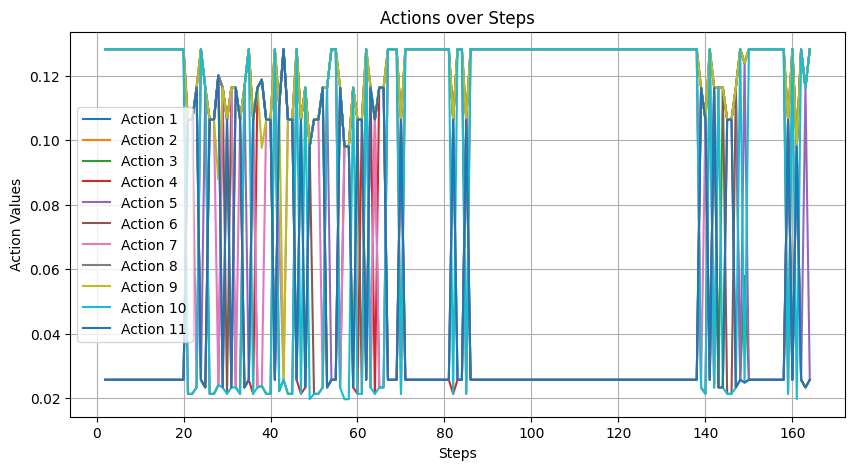

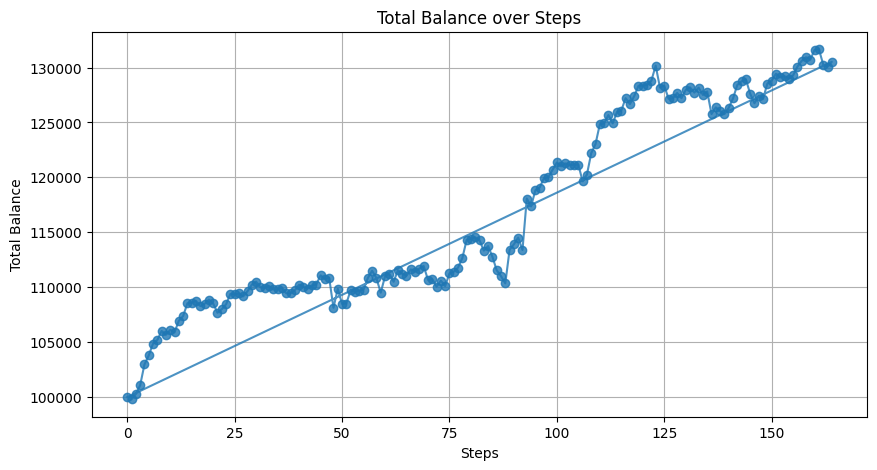

In [5]:

import matplotlib.pyplot as plt
# Create environment for new data
env = DummyVecEnv([lambda: TradingEnv(obs_val)])

# Test Model
done = False
obs_val_pre = env.reset()
env.current_step = 0

# Assuming you have collected these values during your loop
steps = []  # List to store step numbers
actions_list = []  # List to store action values
total_balances = []  # List to store total balances
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_val_pre, deterministic=True)
    obs_val_pre, reward, done, _ = env.step(action)

    steps.append(env.envs[0].current_step)
    actions_list.append(action.flatten())  # Flatten to make it 1D
    total_balances.append(env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices))

    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

# Convert actions to a NumPy array for easier plotting
actions_array = np.array(actions_list)

# Plot Actions over Steps
plt.figure(figsize=(10, 5))
for i in range(actions_array.shape[1]):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot Total Balance over Steps
plt.figure(figsize=(10, 5))
plt.plot(steps, total_balances, marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Steps')
plt.ylabel('Total Balance')
plt.title('Total Balance over Steps')
plt.grid(True)
plt.show()

In [6]:
print(len(obs_val))

166


In [7]:
to_remove = len(obs_val) - 30
print(f"to_remove: {to_remove}")
last_30_days = obs_val[to_remove:, :, :, :]

to_remove: 136


In [8]:
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS
## VALIDATION DATA - 30 DAYS

In [9]:
env = DummyVecEnv([lambda: TradingEnv(last_30_days)])
env.tickers = my_stocks

# Test Model
done = False
obs_row = env.reset()
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action = np.ones((len(my_stocks) + 1), dtype=np.float32) / (len(my_stocks) + 1)
    action = np.array([action])
    obs_row, reward, done, _ = env.step(action)
    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")


num_features: 85
Step: 1, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [4.3884096], Last Price: [ 45.68593216   1.16252494  36.40499878  35.07679749 113.76542664
  40.60973358  47.17878723 120.54270935  34.68671799  83.0750351 ] Position: [ 198. 7804.  249.  258.   79.  223.  192.   75.  261.  109.] Total Balance: 99820.0556512067 Total Reward: 4.388409765378401, Cash Balance: 9336.356153030121, Position Balance: 90483.69949817657
Step: 2, Action: [[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
  0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]], Reward: [0.00538551], Last Price: [ 45.87342834   1.16989017  36.88050079  35.27983093 116.25590515
  40.9459343   47.68583679 121.48568726  34.56455612  82.68474579] Position: [ 199. 7805.  247.  258.   78.  223.  191.   75.  264.  110.] Total Balance: 100450.89367484892 Total Reward: 0.02363380992784771, Cash Balance:

last_30_days: 30
num_features: 85
Step: 1, Action: [[0.12820512 0.12820512 0.02564103 0.02564103 0.02564103 0.12820512
  0.12820512 0.12820512 0.12820512 0.12820512 0.02564103]], Reward: [2.69258], Last Price: [ 45.68593216   1.16252494  36.40499878  35.07679749 113.76542664
  40.60973358  47.17878723 120.54270935  34.68671799  83.0750351 ] Position: [  280. 11006.    70.    72.    22.   315.   271.   106.   368.   154.] Total Balance: 99806.1453861663 Total Reward: 2.6925799781872395, Cash Balance: 2729.303955025398, Position Balance: 97076.8414311409
Step: 2, Action: [[0.12820512 0.12820512 0.02564103 0.02564103 0.02564103 0.12820512
  0.12820512 0.12820512 0.12820512 0.12820512 0.02564103]], Reward: [-0.03360305], Last Price: [ 45.87342834   1.16989017  36.88050079  35.27983093 116.25590515
  40.9459343   47.68583679 121.48568726  34.56455612  82.68474579] Position: [  280. 10989.    69.    72.    22.   313.   269.   105.   371.   155.] Total Balance: 100279.84300064178 Total Reward

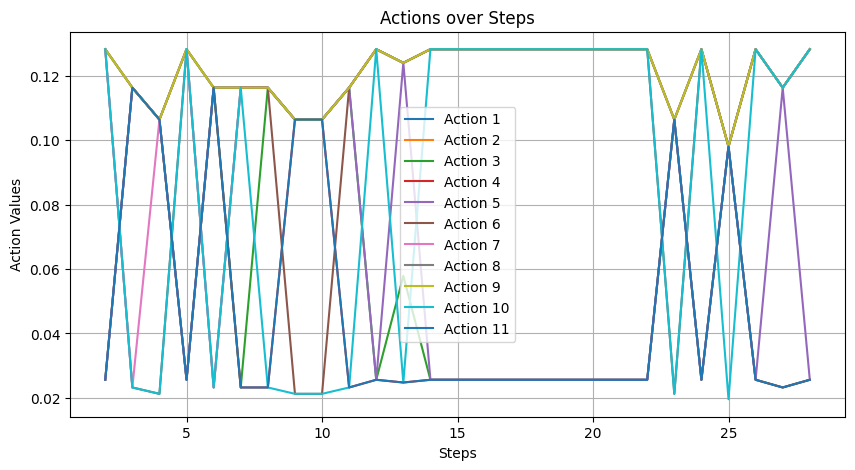

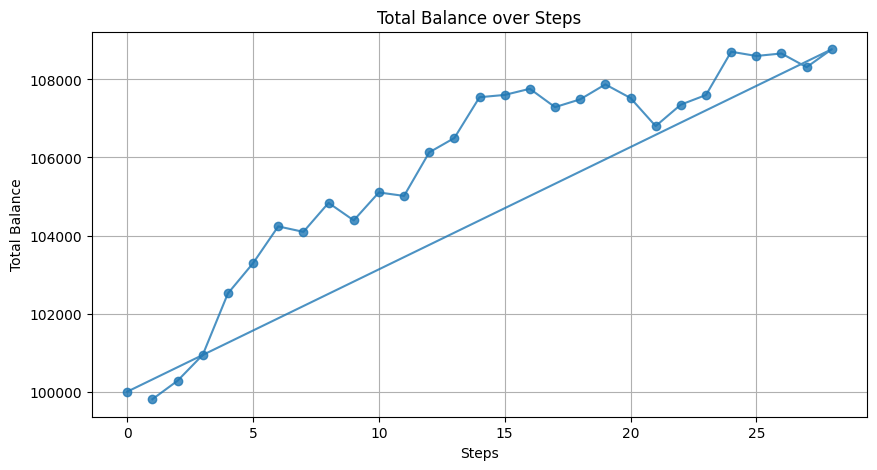

In [10]:
print(f"last_30_days: {len(last_30_days)}")

import matplotlib.pyplot as plt
# Create environment for new data
env = DummyVecEnv([lambda: TradingEnv(last_30_days)])

# Test Model
done = False
obs_val_pre = env.reset()
env.current_step = 0

# Assuming you have collected these values during your loop
steps = []  # List to store step numbers
actions_list = []  # List to store action values
total_balances = []  # List to store total balances
# last_known_explianed_variance = None    
# cons_counter = 0

while not done:
    action, _states = model.predict(obs_val_pre, deterministic=True)
    obs_val_pre, reward, done, _ = env.step(action)

    steps.append(env.envs[0].current_step)
    actions_list.append(action.flatten())  # Flatten to make it 1D
    total_balances.append(env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices))

    print(f"Step: {env.envs[0].current_step}, Action: {action}, Reward: {reward}, Last Price: {env.envs[0].last_prices} Position: {env.envs[0].positions} Total Balance: {env.envs[0].cash_balance + np.sum(env.envs[0].positions * env.envs[0].last_prices)} Total Reward: {env.envs[0].total_reward}, Cash Balance: {env.envs[0].cash_balance}, Position Balance: {np.sum(env.envs[0].positions * env.envs[0].last_prices)}")

# Convert actions to a NumPy array for easier plotting
actions_array = np.array(actions_list)

# Plot Actions over Steps
plt.figure(figsize=(10, 5))
for i in range(actions_array.shape[1]):
    plt.plot(steps[1:-1], actions_array[1:-1, i], label=f'Action {i+1}')

plt.xlabel('Steps')
plt.ylabel('Action Values')
plt.title('Actions over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot Total Balance over Steps
plt.figure(figsize=(10, 5))
plt.plot(steps, total_balances, marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Steps')
plt.ylabel('Total Balance')
plt.title('Total Balance over Steps')
plt.grid(True)
plt.show()

In [11]:
%run "../helpers/data_manipulator.py"
%run "../helpers/yfinance_data_fetcher.py"
fetch_finance_data_for_tickers("BAC", "5y", refresh=True, verbose=False)

data = yf.download("BAC", period="1mo", actions=True, auto_adjust=False)
print(data)


fetch_finance_data_for_tickers: about to load from yfinance: BAC for interval: 5y


[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close Dividends       High        Low       Open  \
Ticker            BAC        BAC       BAC        BAC        BAC        BAC   
Date                                                                          
2025-02-24  44.181187  44.459999      0.00  45.389999  44.439999  45.029999   
2025-02-25  43.664444  43.939999      0.00  44.840000  43.349998  44.529999   
2025-02-26  43.664444  43.939999      0.00  44.549999  43.860001  44.040001   
2025-02-27  43.843315  44.119999      0.00  44.779999  43.939999  44.090000   
2025-02-28  45.810898  46.099998      0.00  46.200001  44.200001  44.320000   
2025-03-03  45.274288  45.560001      0.00  46.959999  45.220001  46.209999   
2025-03-04  42.402409  42.669998      0.00  44.840000  42.029999  44.730000   
2025-03-05  42.024796  42.290001      0.00  42.730000  41.709999  42.650002   
2025-03-06  41.199997  41.459999      0.00  41.889999  40.959999  41.590000   
2025-03-07  41.400002  41.400002      0.26  41.73000